## Imports

In [1]:
import os

try:
    from occultence import *
except:
     os.chdir("../..")
    
import occultence
occultence.version()

'0.5.7'

# Run LC all the way through `occultence`

(0.99, 1.015)

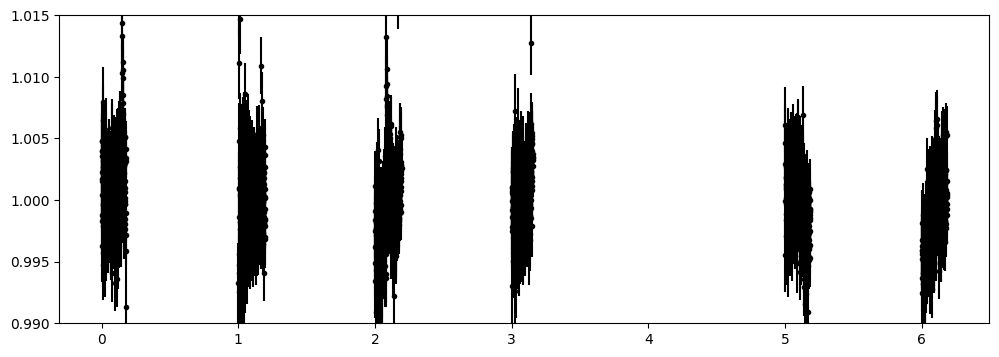

In [2]:
pre_bin = False
file_name = "../../Data/0000000000000000001.csv"
gaia_id = file_name.split("/")[-1].replace(".csv","")

data = pd.read_csv(file_name)

t = data["bjd"].values - data["bjd"].values[0]
f = data["diff_flux_use"].values
ferr = data["diff_error"].values

# f *= np.linspace(1,1.01, len(t)) # add a linear trend for the GP to remove
plt.figure(figsize=(12,4))
plt.errorbar(t,f,ferr,fmt='k.')
plt.ylim(0.99,1.015)

In [3]:
targ = LightCurve(name = "secondLC",
                  time = t,
                  flux = f,
                  uncertainty = np.abs(ferr),
                  telescope = "None",
                  filter="None",
                  metadata={'R_star':0.1*u.R_sun, 'M_star':0.1*u.M_sun})

🤖⚠ Warning! The time array is not an astropy.Time object, therefore there is no info about the 
format or scale.
We will assume that it is JD and TDB from here on! ⚠🤖



In [4]:
targ, targ.bin(dt=0.01*u.d)

(<🌟 Lightcurve secondLC (1912t) 🌟>, <🌟 Lightcurve secondLC_bin (112t) 🌟>)

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


array([<Axes: ylabel='flux'>, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
       <Axes: xlabel='Time [d]'>], dtype=object)

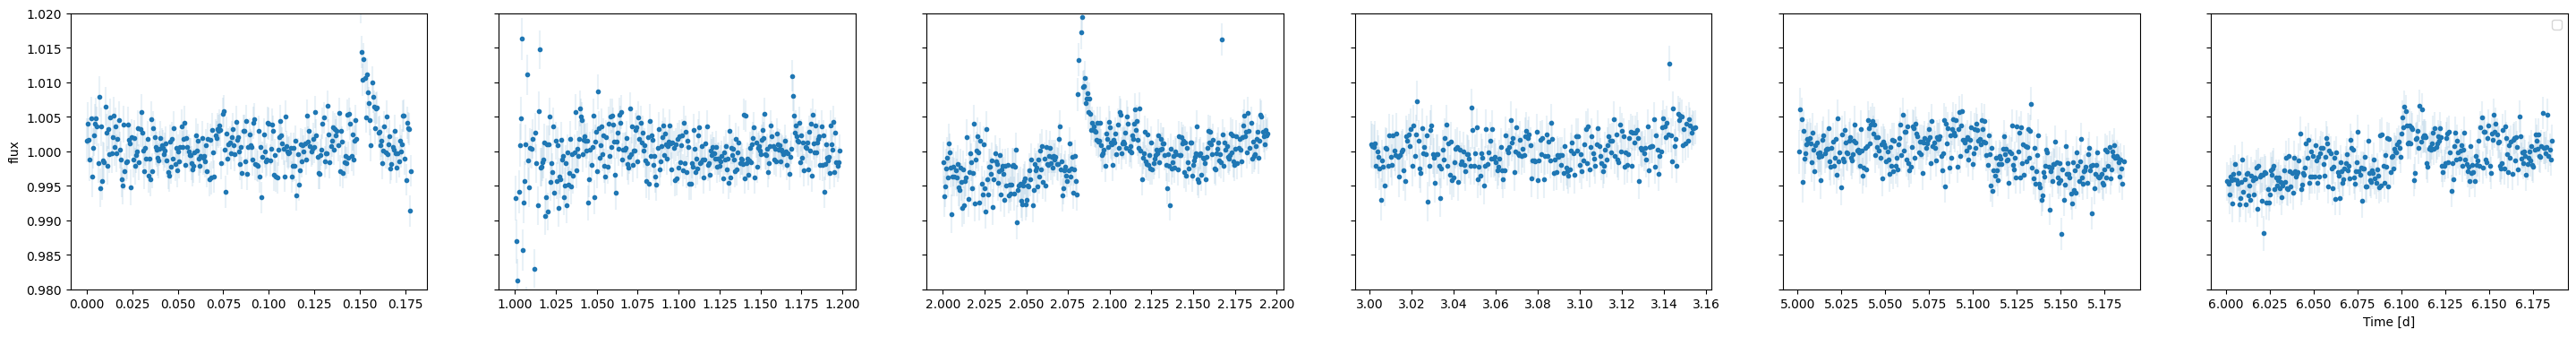

In [5]:
targ.plot()

In [6]:
targ_with_transit = targ.inject_transit(per=2.55*u.d, 
                                        epoch=0.025 * u.d, 
                                        inc=90 * u.degree, 
                                        rp=1 * u.R_earth, 
                                        ld=[0.3,0.3])

In [9]:
# b = targ_with_transit.inject_flares(3)

In [10]:
# b.timelike

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


array([<Axes: ylabel='transit_model'>, <Axes: >, <Axes: >, <Axes: >,
       <Axes: >, <Axes: xlabel='Time [d]'>], dtype=object)

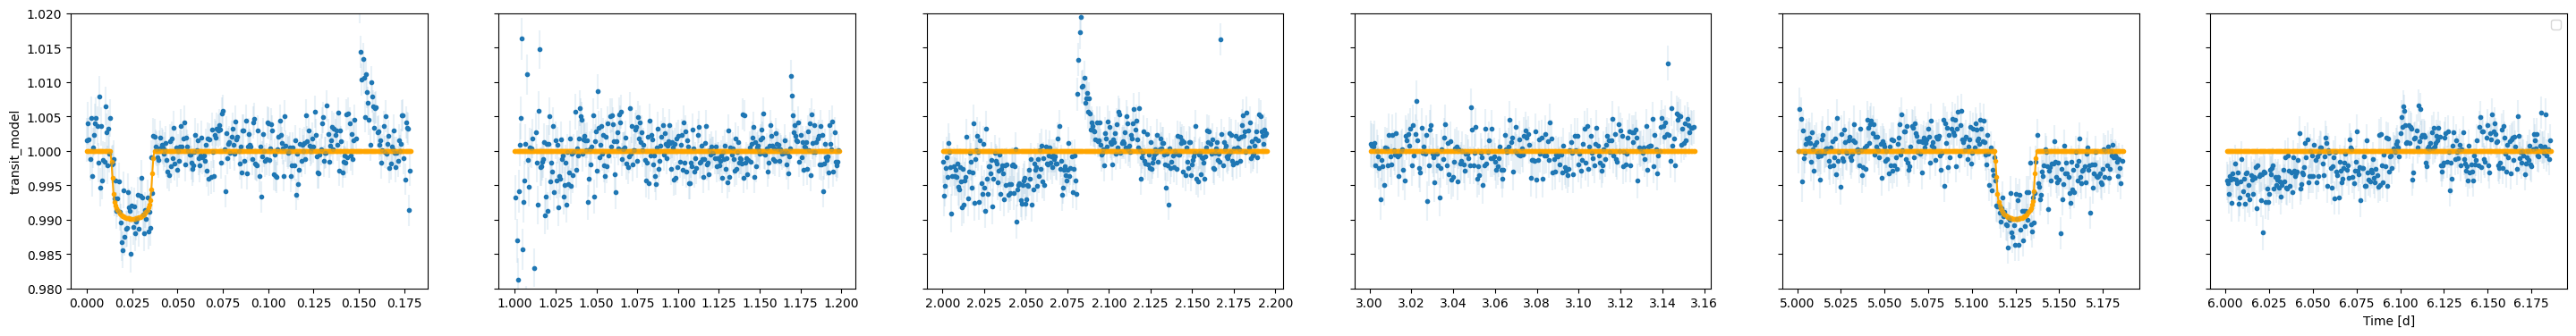

In [12]:
ax=targ_with_transit.plot()
targ_with_transit.plot(quantity="transit_model", color='orange', ax=ax, linestyle="-")
# targ_with_transit.plot(quantity="flare_model_1", color='orange', ax=ax, linestyle="-")

In [118]:
# detrended_targ = t3.lombscargle_detrend(plot=True, ls_binning=30*u.minute,
#                                   minimum_frequency=1/(30*u.d),
#                                   maximum_frequency=1/(0.5*u.d),
#                                   samples_per_peak=10,
#                                   npeaks=1,
#                                   nsigma=3)

Use `.detect_flares_sclip` to find and mask flares:

/Users/catrionamurray/anaconda3/envs/occultence/lib/python3.9/site-packages/numpy/core/fromnumeric.py:784: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  a.partition(kth, axis=axis, kind=kind, order=order)
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.



            There are 2 flare candidates with >30.0 s over 3$\sigma$
            


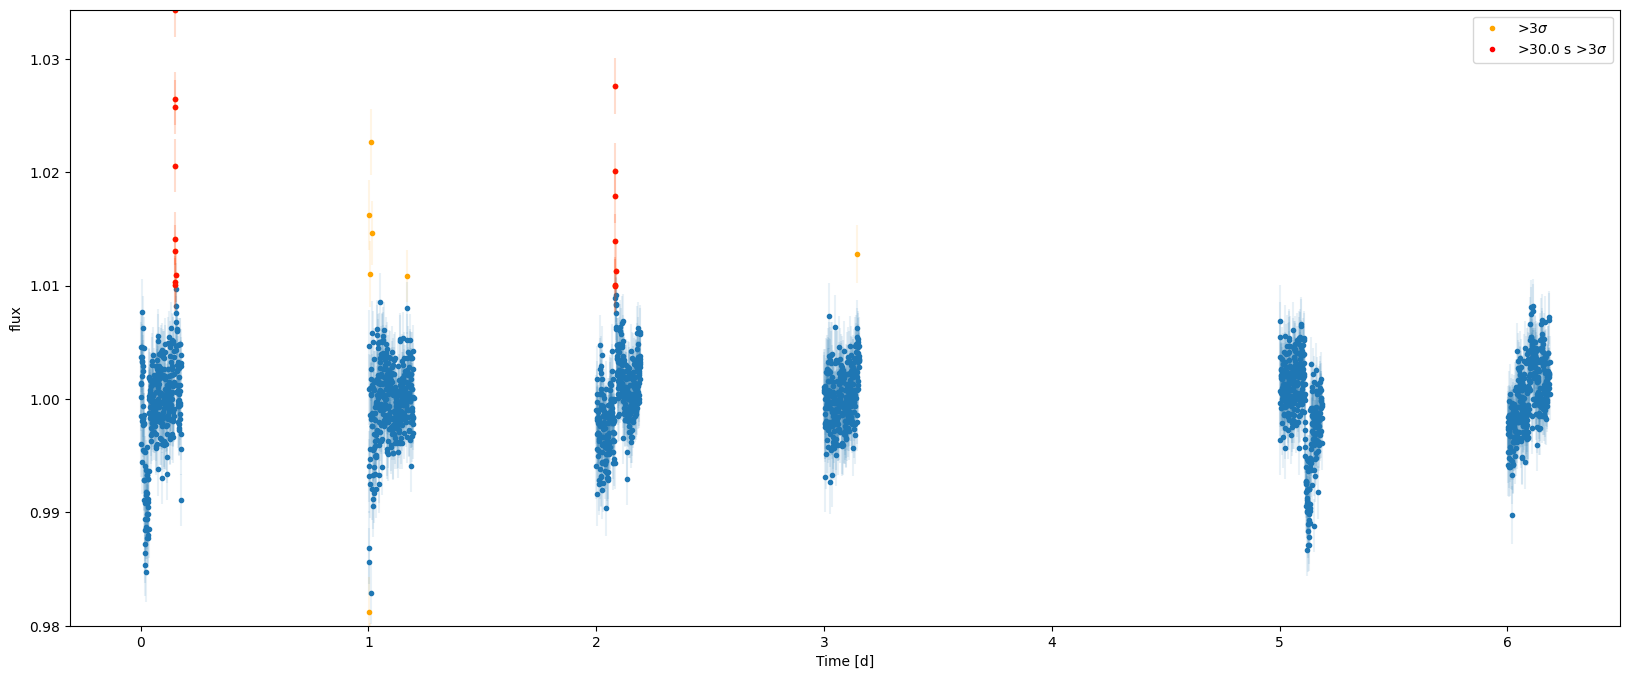

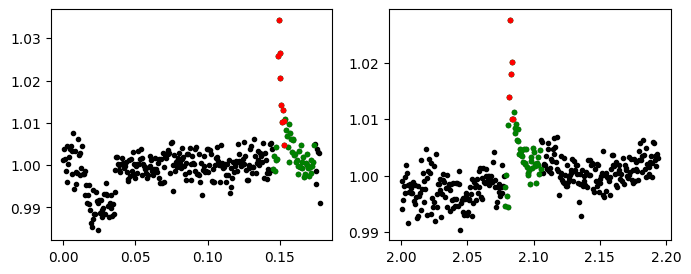

In [119]:
t3 = t2.detect_flares_sclip(plot=True, min_flare_separation=60*u.minute, min_flare_duration=30*u.s, tbuffer_after=30*u.min, 
                                       n_consecutive_points=2, n_points=2,
                                        global_sc_kw={'nsigma_upper': 3, 'nsigma_lower': 5},
                                        local_sc_kw={'nsigma_upper': 3, 'nsigma_lower': np.inf, 'running_median_boxsize': 0.2},)

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


array([<Axes: ylabel='flux'>, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
       <Axes: xlabel='Time [d]'>], dtype=object)

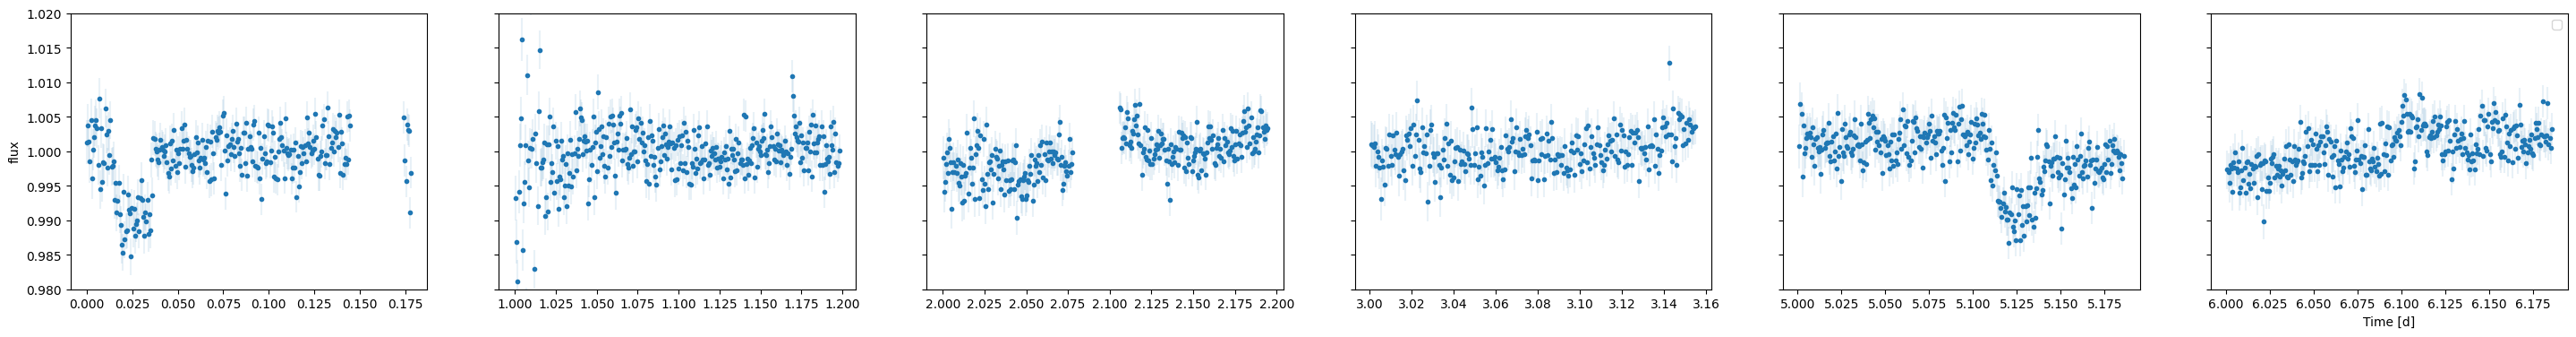

In [120]:
t3.plot()

Bin LC coarsely to GP-detrend.

/Users/catrionamurray/anaconda3/envs/occultence/lib/python3.9/site-packages/numpy/lib/nanfunctions.py:1217: RuntimeWarning: All-NaN slice encountered
  return function_base._ureduce(a, func=_nanmedian, keepdims=keepdims,
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


array([<Axes: ylabel='flux'>, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
       <Axes: xlabel='Time [d]'>], dtype=object)

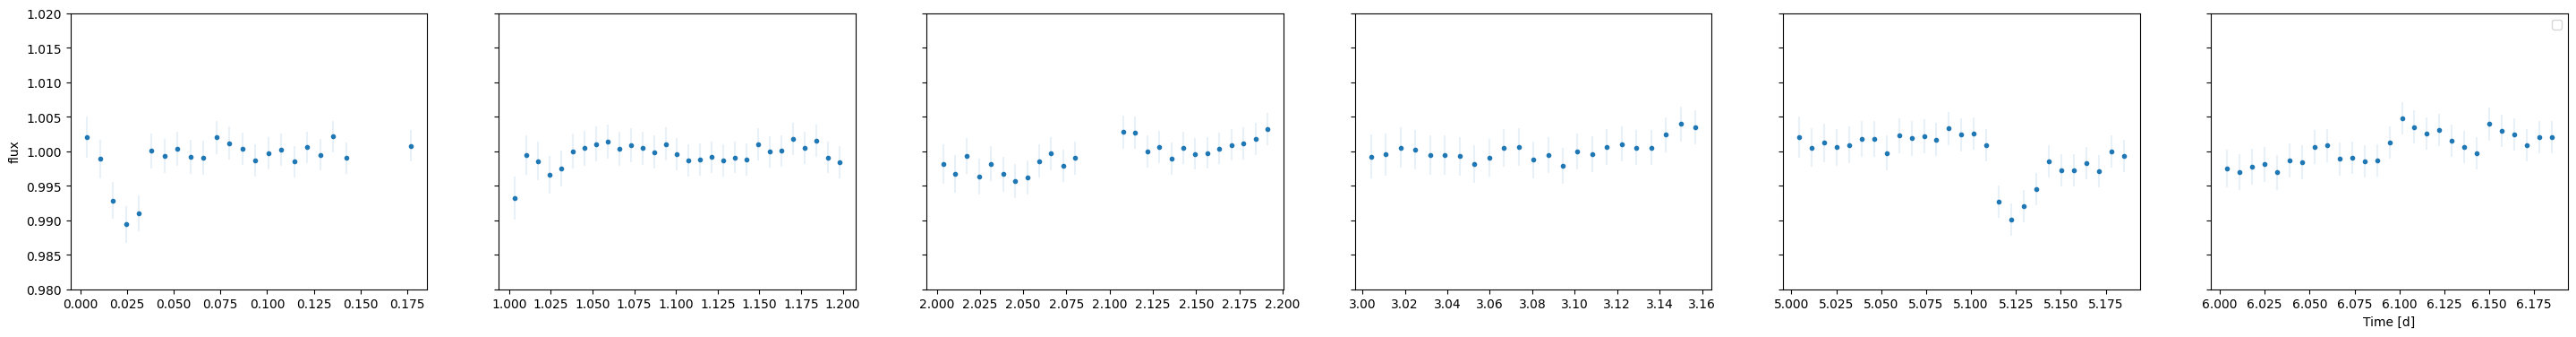

In [121]:
t3_bin = t3.bin(dt = 10*u.min)
t3_bin = t3_bin.remove_nans()

t3_bin.telescope = np.array([t3_bin.telescope[0]] * t3_bin.ntime)
t3_bin.filter = np.array([t3_bin.filter[0]] * t3_bin.ntime)

t3_bin.plot()

Perform an initial BLS search to mask transits before running detrending (to avoid over-fitting the transits)

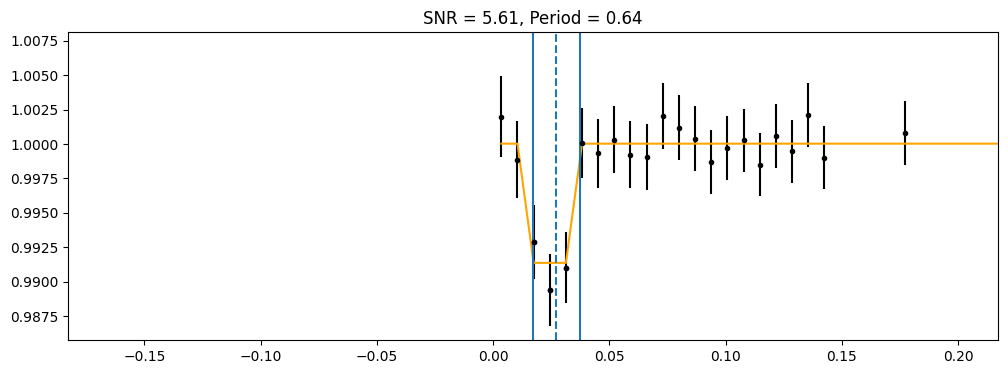

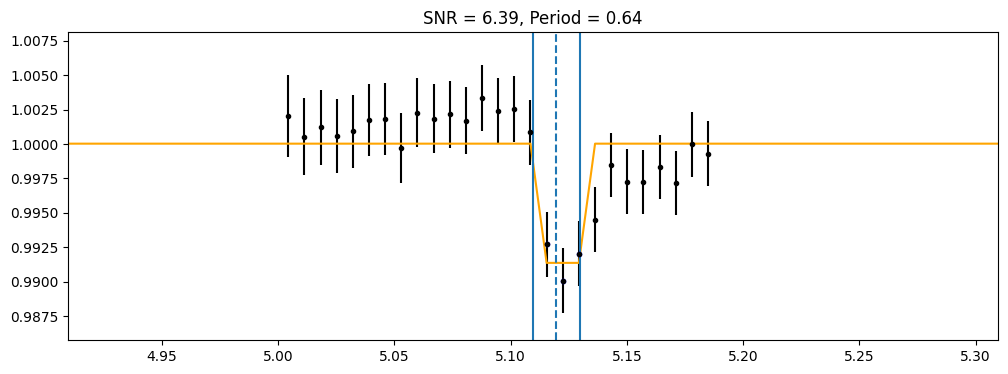

In [122]:
t4 = find_transits(t3_bin, minimum_n_transit=2, transit_durations=[0.01, 0.02, 0.03, 0.04], 
                   plot=True, return_all_transits=False, obj="snr", minimum_period=None, maximum_period=None)[0]

In [123]:
t4.metadata

{'name': 'firstLC_inject_normalized_clean_sigmaclipped_flaresremoved_bin_bls_0',
 'target': 'firstLC',
 'R_star': <Quantity 0.1 solRad>,
 'M_star': <Quantity 0.1 solMass>,
 'injected_planet': {'period': [<Quantity 2.55 d>],
  'epoch': [<Quantity 0.025 d>],
  'inc': [<Quantity 90. deg>],
  'rp': [<Quantity 1. earthRad>],
  'a': [<Quantity 3.64584257 solRad>],
  'a_Rs': [<Quantity 36.45842565>],
  'ld': [[0.3, 0.3]],
  'depth': [<Quantity 0.00840502>],
  'duration': [<Quantity 0.02430817 d>]},
 'normalization': [{'norm_og_median': 1.0002498164325095},
  {'norm_og_median': 1.0000377353439704},
  {'norm_og_median': 0.9993019815842068},
  {'norm_og_median': 0.9999339071628168},
  {'norm_og_median': 0.9991873513462306},
  {'norm_og_median': 0.9983136839625296}],
 'thresholds': {},
 'flares_detected': {'nflares': 2,
  'thresholds': {'duration': <Quantity 30. s>,
   'sigma': 3,
   'separation': <Quantity 60. min>},
  'flare_regions': [[257, 308], [795, 843]],
  'flare_frequency': <Quantity 2.1

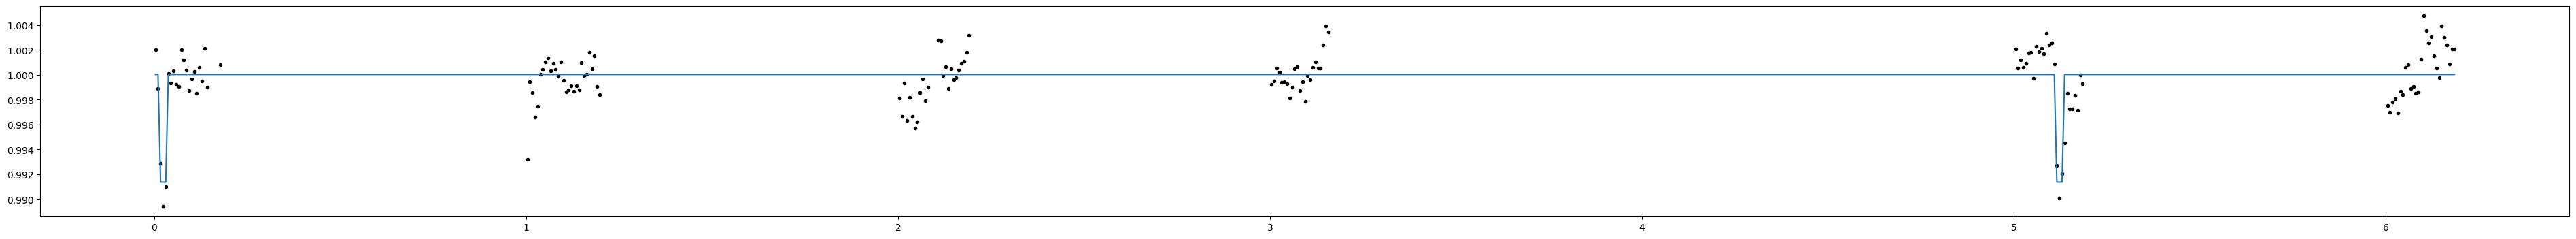

In [124]:
plt.figure(figsize=(48,4))
plt.plot(t3_bin.time.value, t3_bin.flux, 'k.')
plt.plot(t4.time.value, t4.timelike['BLS_model'])

In [125]:
t4

<🌟 Lightcurve firstLC_inject_normalized_clean_sigmaclipped_flaresremoved_bin_bls_0 (153t) 🌟>

Mask transits found

In [126]:
in_transit = t4.metadata['BLS_transits_ind']
t4.masks['transit'] = np.zeros(t4.ntime)
t4.masks['transit'][in_transit] = 1.0
init_transits_masked = t4.clean(zero_flux_removal=False, nan_flux_removal=False,
                                              bad_weather_removal=False, threshold_removal=False,
                                              dust_removal=False, cosmics_removal=False)
t4_mask = init_transits_masked

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


array([<Axes: ylabel='flux'>, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
       <Axes: xlabel='Time [d]'>], dtype=object)

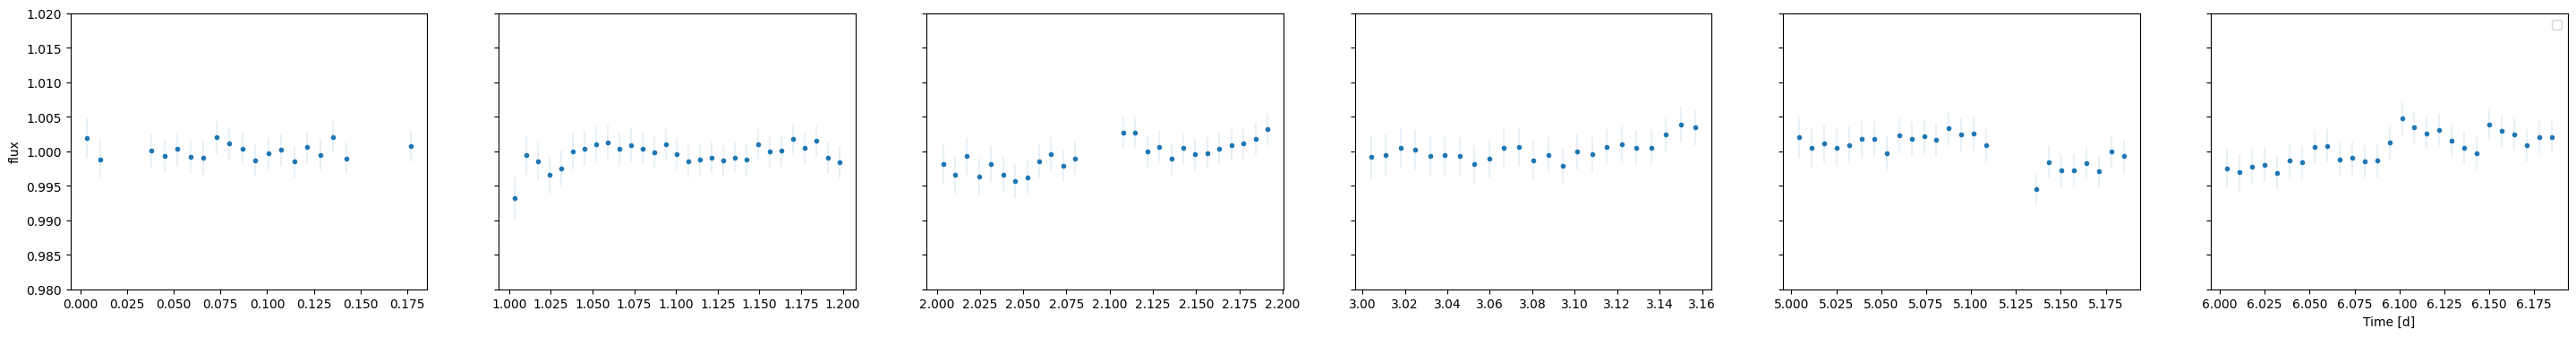

In [127]:
t4_mask.plot()

Perform GP-detrending with a Squared-Exponential kernel. Initial hyperparameters may need tuning?

Fitted GP HPs: [-26.92322547 -12.89560881  -3.87120101]

Fitted GP HPs: [-27.76182738 -12.87993994  -3.87120101]

Fitting rotation with square-exponential GP...
Initial Parameter Vector:  [-6.03322791 -6.30518155 -2.30258509]
Initial Params: AMP =  0.0018268144859182043 , SQEXP=  0.10000000000000002 , JITTER =  0.002397741770828749
Initial ln-likelihood: 291.86
Fitted GP HPs: [-29.57877061 -12.85957266  -3.87120101]
Fitted Params: AMP =  2.601109007116602e-06 , SQEXP=  0.02083333333333333 , JITTER =  1.425946208714654e-13
Final ln-likelihood: 693.81


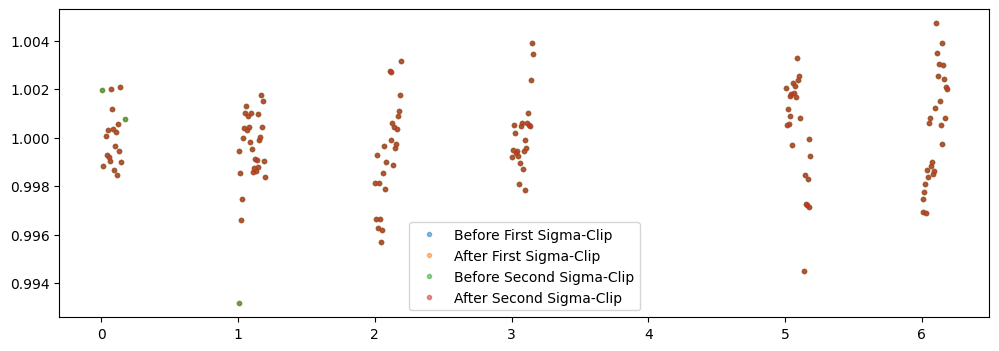

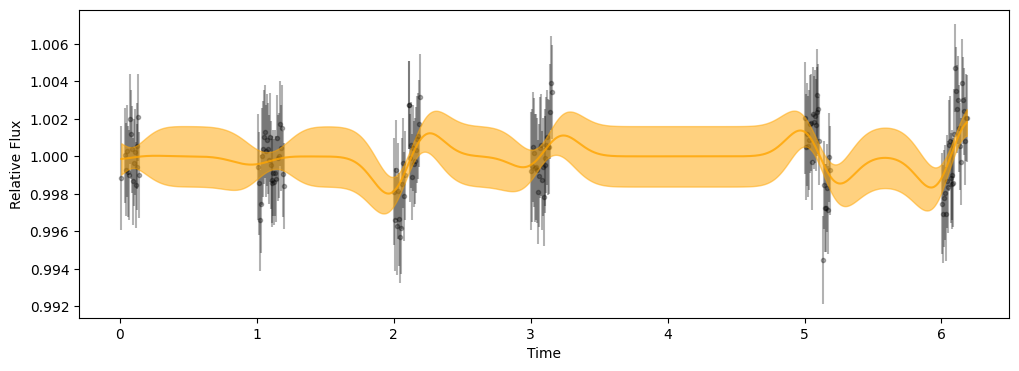

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


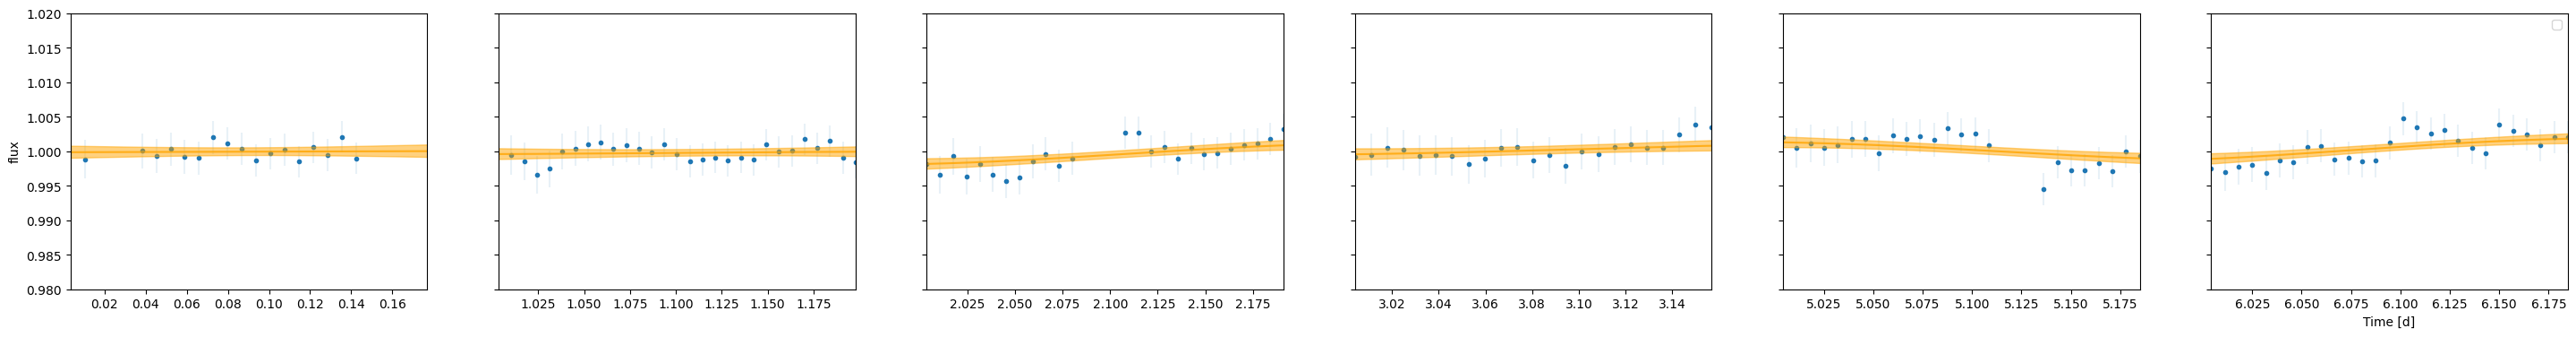

In [128]:
t5 = t4_mask.gp_detrend(use_uncertainties=False, verbose=True, amp_metric=None, sqexp_metric=0.1, sqexp_metric_bound=[np.log((0.5*u.hr).to_value('d')), np.log((np.max(t4_mask.time)-np.min(t4_mask.time)).value)], plot=True)

## Run full IR

In [13]:
per=2.55*u.d
epoch=0.025 * u.d
inc=90 * u.degree
rp=1 * u.R_earth
ld=[0.3,0.3]

planets = targ_with_transit.create_lots_of_transit_params(nfake=1, 
                                                          minimum_planet_radius=rp, 
                                                          maximum_planet_radius=rp,
                                                          minimum_period=per, 
                                                          maximum_period=per,
                                                        )
planets

,logP,phase,cosi,r_p,depth,duration,epoch,a,a_Rs,injected,...,rec_depth,rec_duration,rec_epoch,run,snr,target,r_s,m_s,teff,spt
0,0.40654,0.717859,0.00023,1.0,0.008405017877225193,0.024307,1.830541,3.6458425652160784 solRad,36.458425652160784,0.0,...,0.0,0.0,0.0,0.0,0.0,secondLC_inject,0.1 solRad,0.1 solMass,None,None


1/1...


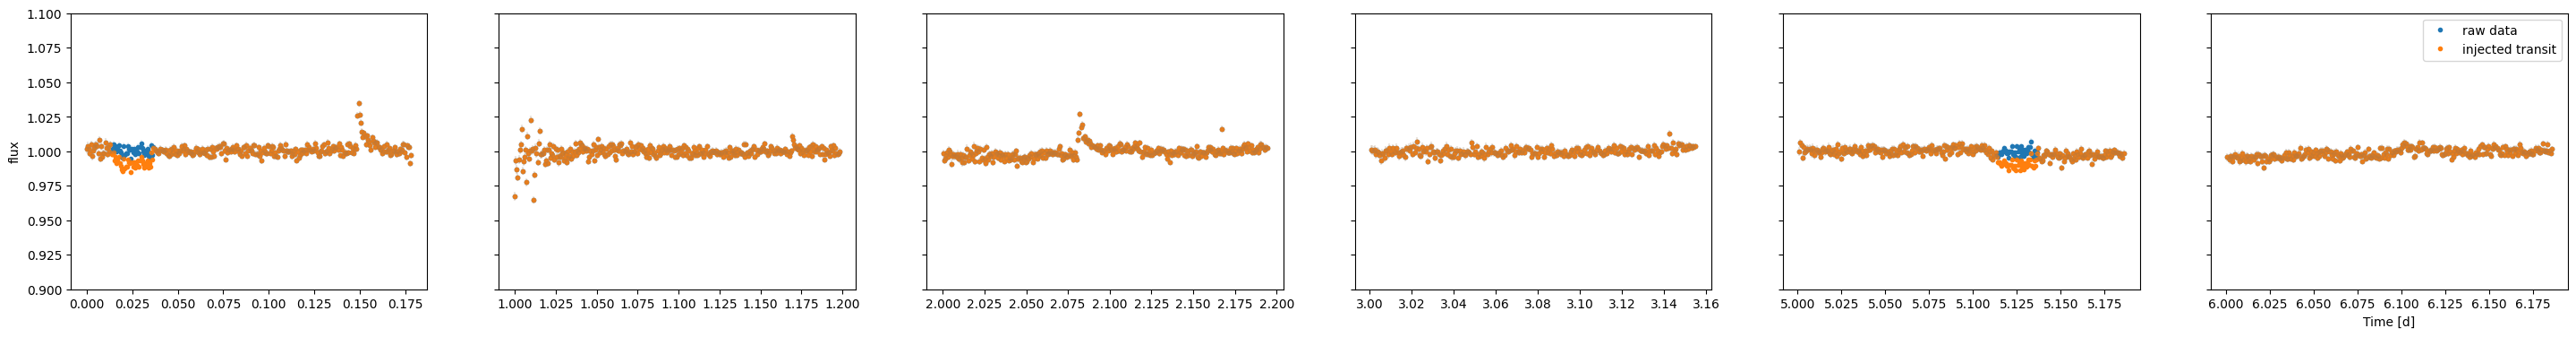

Masking NaN fluxes...
Masking zero fluxes...
Masking cosmic ray hits...



            0.05230125523012552% of data is flagged as cosmics ⚡.
            
Time to clean LC: 0.6118080615997314


/Users/catrionamurray/anaconda3/envs/occultence/lib/python3.9/site-packages/numpy/core/fromnumeric.py:784: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  a.partition(kth, axis=axis, kind=kind, order=order)
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.



            There are 2 flare candidates with >30.0 s over 3$\sigma$
            


Time to remove flares: 0.665787935256958


/Users/catrionamurray/anaconda3/envs/occultence/lib/python3.9/site-packages/numpy/lib/nanfunctions.py:1217: RuntimeWarning: All-NaN slice encountered
  return function_base._ureduce(a, func=_nanmedian, keepdims=keepdims,


Running BLS Search
Number of Periods Checked:  47143
Period:  0.6365635172023879
Duration:  0.02
Depth:  0.008453271501519007
Power:  8.183614912722181


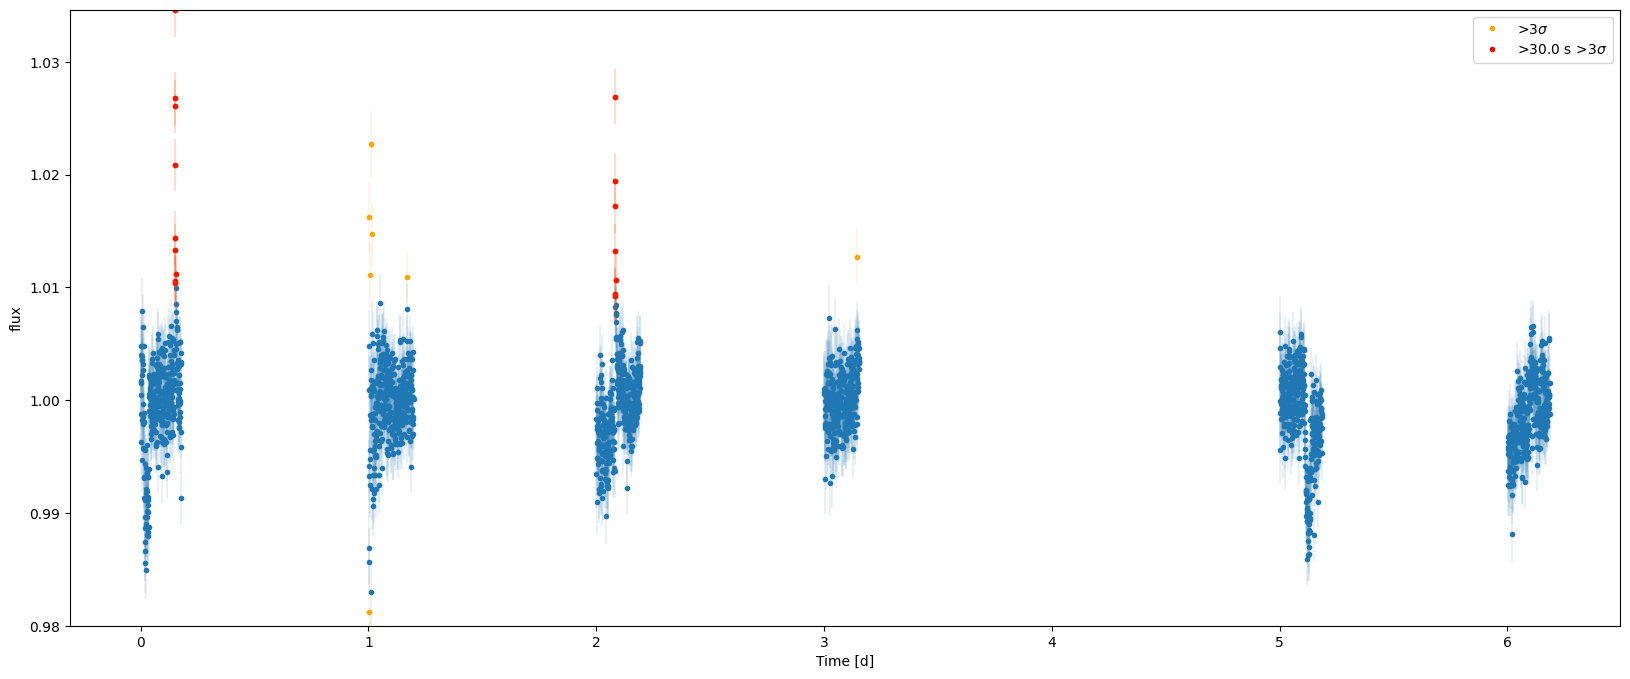

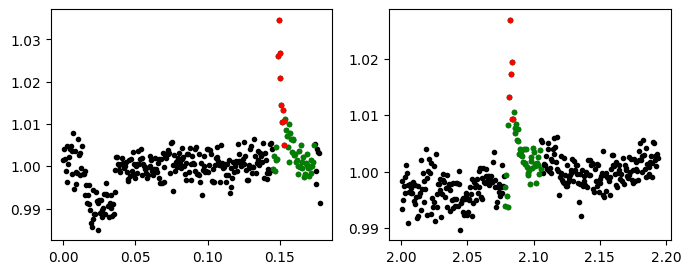

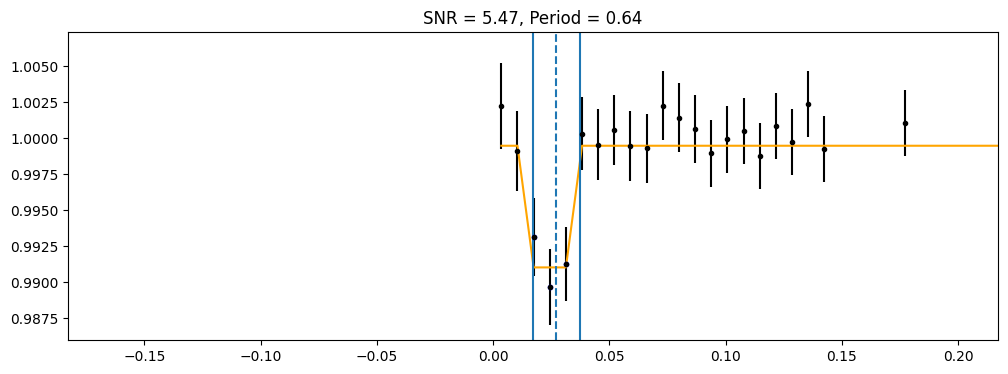

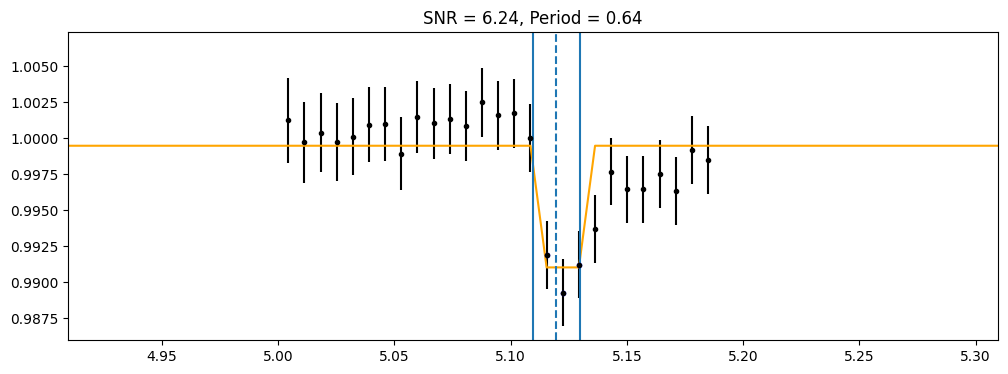

Time to BLS before detrending: 1.1400680541992188
Fitting rotation with square-exponential GP...
Initial Parameter Vector:  [-6.0299933  -6.31289892 -2.30258509]
Initial Params: AMP =  0.0018127705333067586 , SQEXP=  0.10000000000000002 , JITTER =  0.0024055100891274
Initial ln-likelihood: 291.63
Fitted GP HPs: [-26.92322547 -12.89560881  -3.87120101]
Fitted Params: AMP =  2.5090438477813815e-06 , SQEXP=  0.02083333333333333 , JITTER =  2.029512555294125e-12
Final ln-likelihood: 696.88


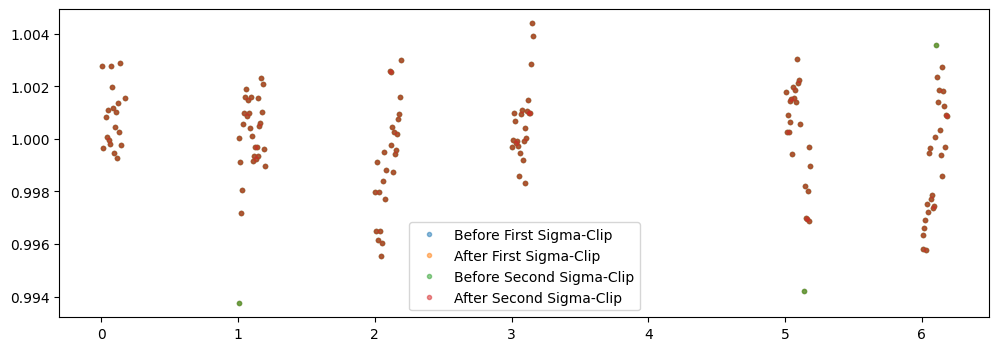

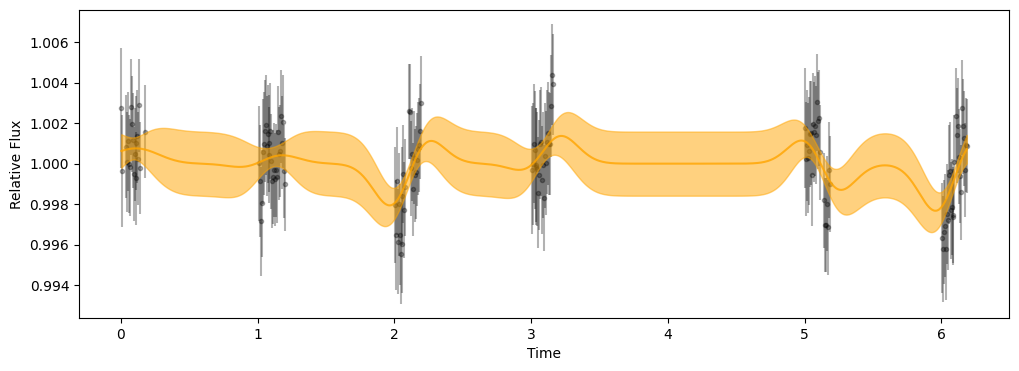

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


Time to detrend: 2.057835817337036


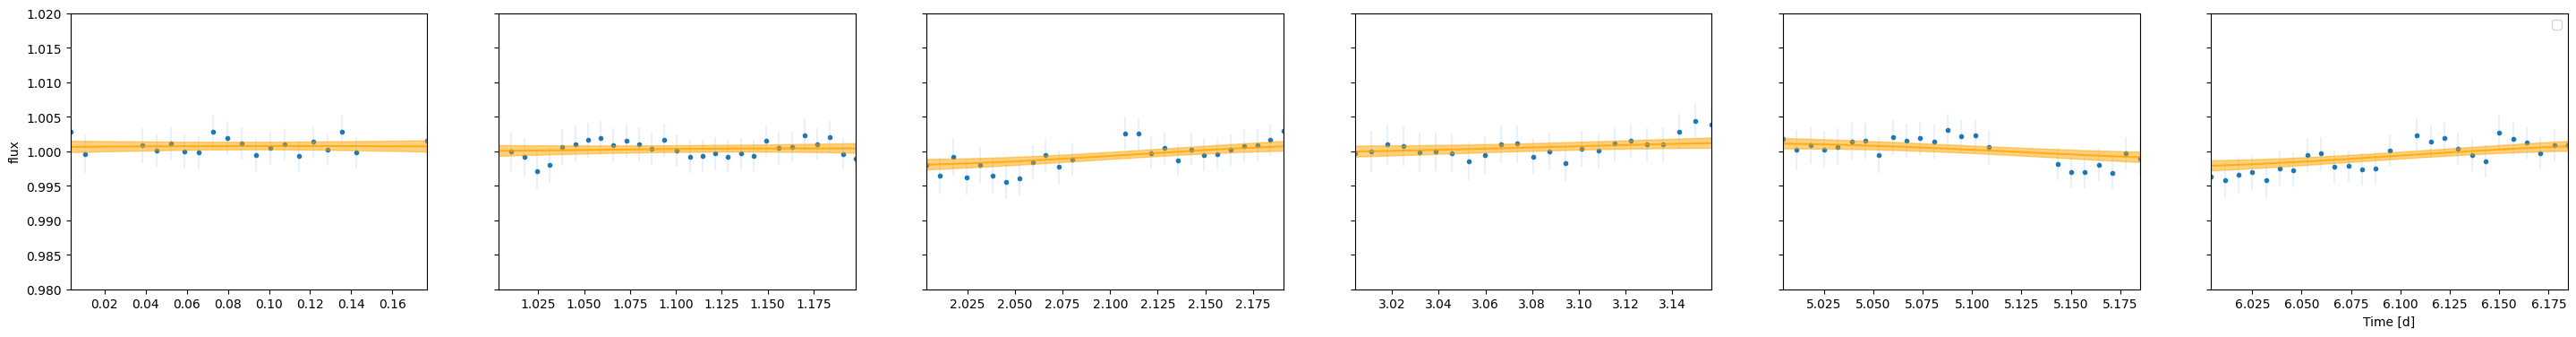

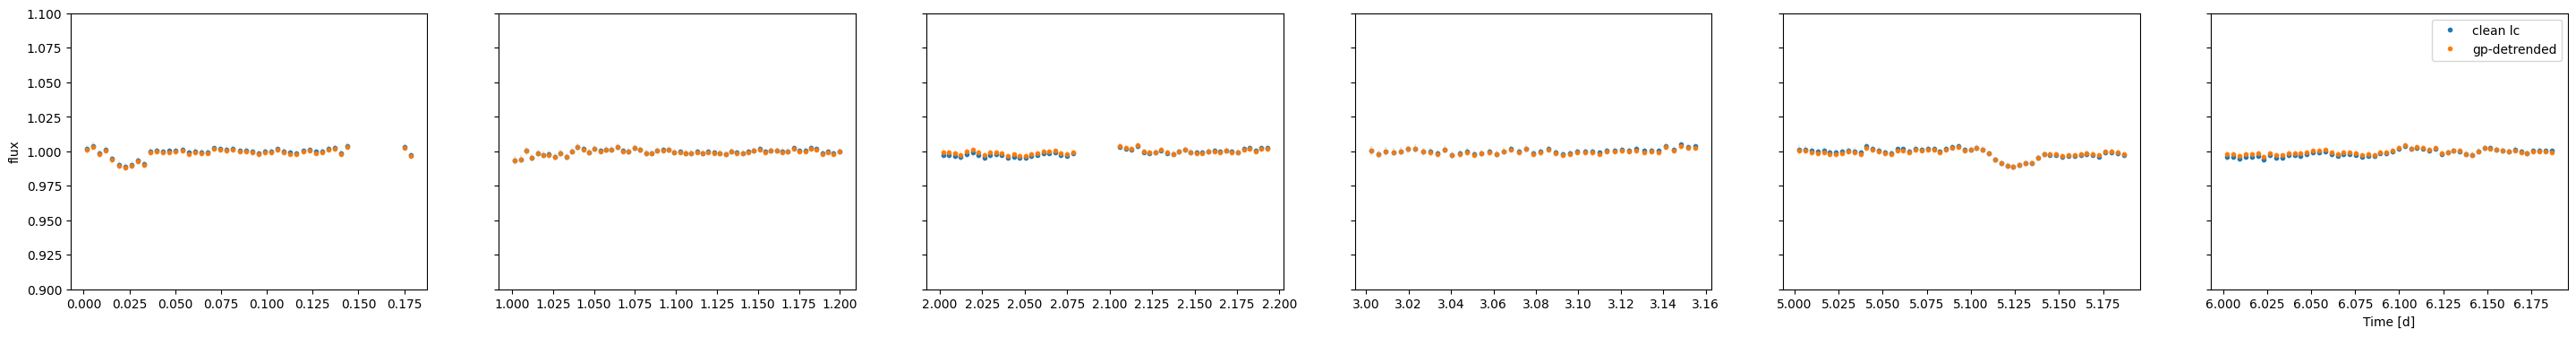

Running BLS Search
Number of Periods Checked:  47196
Period:  0.6377387224946418
Duration:  0.02
Depth:  0.009007126152835648
Power:  12.338280161785178


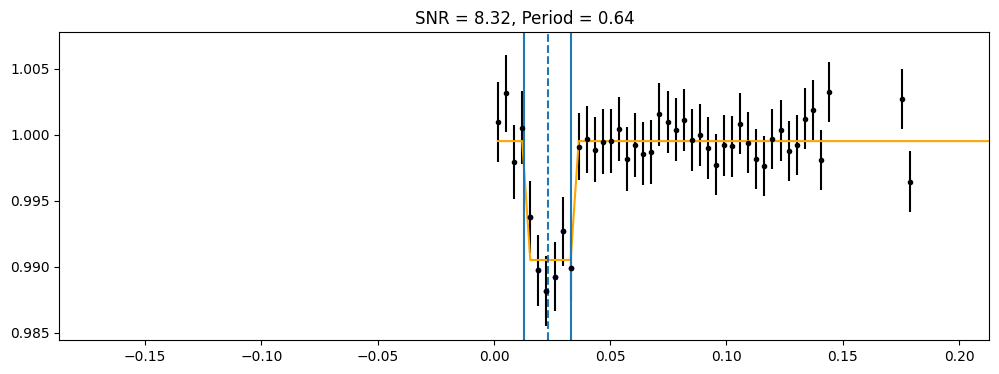

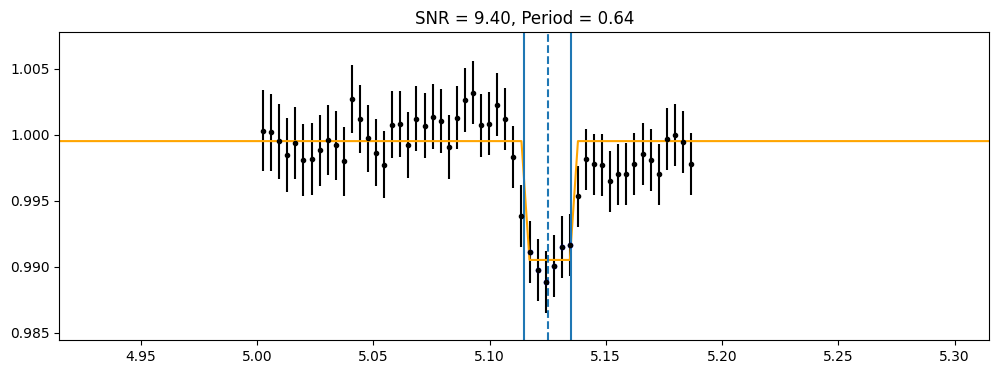

Time to BLS search: 0.9859750270843506
Transit was found - checking if it matches the injected transit!
Planet was successfully recovered
No transit found!

Time to inject-recover 1 planets: 7.6057868003845215
Planets recovered: 100.0%
But did all of those planets transited during the observation window?...
Observed Planets recovered: 100.0%


In [14]:
x = full_injection_recovery(targ, lcs_with_transits=[targ_with_transit],
                                 planets=planets,
                                 nfake=1,
                                 minimum_planet_radius=0.25 * u.R_earth, 
                                 maximum_planet_radius=1 * u.R_earth,
                                 minimum_period=0.5 * u.d, 
                                 maximum_period=2 * u.d, 
                                 ld=[0.3,0.3],
                                 clean_kw = {'dust_removal': False, 'bad_weather_removal': False,'cosmics_removal': True,
                                             'threshold_removal':False, 'cosmic_boxsize':0.01, 'cosmic_nsigma':5, 'verbose':True},
                                 flare_kw = {'plot':True, 'min_flare_separation':60*u.minute, 'min_flare_duration':30*u.s,
                                             'tbuffer_after':30*u.min, 'n_consecutive_points':2, 'n_points':2, 
                                             'global_sc_kw':{'nsigma_upper': 3, 'nsigma_lower': 5}, 
                                             'local_sc_kw':{'nsigma_upper': 3, 'nsigma_lower': np.inf, 'running_median_boxsize': 0.2},},
                                 detrend_method = "gp", 
                                 detrend_bin = 10 * u.minute,
                                 detrend_kw = {'do_first_sigma_clip': True, 'do_second_sigma_clip': True,
                                               'running_median_boxsize': 0.08, 'nsigma': 3, 'plot': True, 'verbose':True,
                                               'use_uncertainties':False, 'amp_metric':None, 'sqexp_metric':0.1, 
                                               'sqexp_metric_bound':[np.log((0.5*u.hr).to_value('d')), 
                                                                     np.log((np.max(targ.time)-np.min(targ.time)).value)]},
                                bls_kw = {"minimum_period":None, "maximum_period":None, 'minimum_n_transit':2, 'obj':'snr',
                                          'return_all_transits':False, 'transit_durations':[0.01,0.02,0.03,0.04], 'plot':True, 
                                          'verbose': True}, 
                                bls_bin=5 * u.minute,
                                recovery_kw = {'condition_on_epoch':1 * u.hour, 'min_n_transits': 1, 'meet_condition': 'any'},                           
                                verbose=True, plot=True, time_this_process=True)

In [15]:
lcs, lcs_clean, lcs_gp, lcs_bls, planets_df = x